# Notebook 2 — Sequence-to-sequence with autoregressive recurrent models

This notebook follows the  recipe card for autoregressive recurrent models.

**Task:** given the first part of an ECG signal, predict the future part of the same signal.

We use **ECG5000**, a small biomedical time-series dataset.  
Each original sample is one ECG sequence of length `140`.  
We split each sequence into:

- **input sequence**: first `T_x = 90` time steps
- **target output sequence**: last `T_y = 50` time steps

So each training sample is:

- `x_i in R^[T_x x F_x]`
- `y_i in R^[T_y x F_y]`

Here the signal is univariate, so:

- `F_x = 1`
- `F_y = 1`

The model is an **encoder-decoder recurrent model**:

`x -> Encoder -> context c -> Decoder -> y_hat_1, y_hat_2, ..., y_hat_Ty`

The decoder is **autoregressive**:
- during training, it uses the **true previous target** (**teacher forcing**) you can changfe this if you dont want it or want to see what happens if you disable it
- during inference, it uses its **own previous prediction**

## 1. Load libraries

We use standard Python tools, PyTorch, and a few utilities for plotting and data splitting.

In [1]:
# ---------------------------------------
# 1) Load libraries
# ---------------------------------------
from pathlib import Path
import urllib.request
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# Reproducibility: fix random seeds where possible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection: use GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Load your sequence dataset `D`

For an autoregressive sequence-to-sequence task, each training sample is usually a pair:

`D = {(x_1, y_1), ..., (x_k, y_k)}`

where:

- `x_i in R^[T_x x F_x]`: input sequence
- `y_i in R^[T_y x F_y]`: target output sequence

In this notebook, each ECG signal has length `140`.  
We split it into:

- input prefix: `T_x = 90`
- future target suffix: `T_y = 50`

So the model must read the observed prefix and generate the future suffix.

In [3]:

# ---------------------------------------
# 2) Load ECG5000 and convert it into
#    autoregressive input/output sequence pairs
# ---------------------------------------

# Folder where we keep the raw files
data_dir = Path("data/ecg5000")
data_dir.mkdir(parents=True, exist_ok=True)

train_path = data_dir / "ECG5000_TRAIN"
test_path = data_dir / "ECG5000_TEST"

# Public GitHub mirror of ECG5000
download_urls = {
    "ECG5000_TRAIN": "https://raw.githubusercontent.com/tejaslodaya/timeseries-clustering-vae/master/data/ECG5000/ECG5000_TRAIN",
    "ECG5000_TEST": "https://raw.githubusercontent.com/tejaslodaya/timeseries-clustering-vae/master/data/ECG5000/ECG5000_TEST",
}

def download_if_needed(path: Path, url: str) -> None:
    """Download one file only if it is not already present."""
    if path.exists():
        print(f"Found existing file: {path}")
        return

    print(f"Downloading {path.name} ...")
    urllib.request.urlretrieve(url, path)
    print(f"Saved to: {path}")

download_if_needed(train_path, download_urls["ECG5000_TRAIN"])
download_if_needed(test_path, download_urls["ECG5000_TEST"])

# IMPORTANT: ECG5000 files are comma-separated
train_df = pd.read_csv(train_path, header=None, sep=",")
test_df = pd.read_csv(test_path, header=None, sep=",")

print("Train raw shape:", train_df.shape)
print("Test raw shape: ", test_df.shape)

# First column = class label, remaining columns = ECG sequence values
# We do not use the class label in this forecasting notebook.
X_train_raw = train_df.iloc[:, 1:].to_numpy(dtype=np.float32)
X_test_raw = test_df.iloc[:, 1:].to_numpy(dtype=np.float32)

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape: ", X_test_raw.shape)

# Normalize using train statistics only
train_mean = X_train_raw.mean()
train_std = X_train_raw.std() + 1e-8

X_train_norm = (X_train_raw - train_mean) / train_std
X_test_norm = (X_test_raw - train_mean) / train_std

Found existing file: data/ecg5000/ECG5000_TRAIN
Found existing file: data/ecg5000/ECG5000_TEST
Train raw shape: (5000, 141)
Test raw shape:  (4500, 141)
X_train_raw shape: (5000, 140)
X_test_raw shape:  (4500, 140)


Input train shape X_train: (5000, 90, 1)
Target train shape Y_train: (5000, 50, 1)
Input test shape  X_test:  (4500, 90, 1)
Target test shape Y_test:  (4500, 50, 1)
T_x = 90, T_y = 50, F_x = 1, F_y = 1


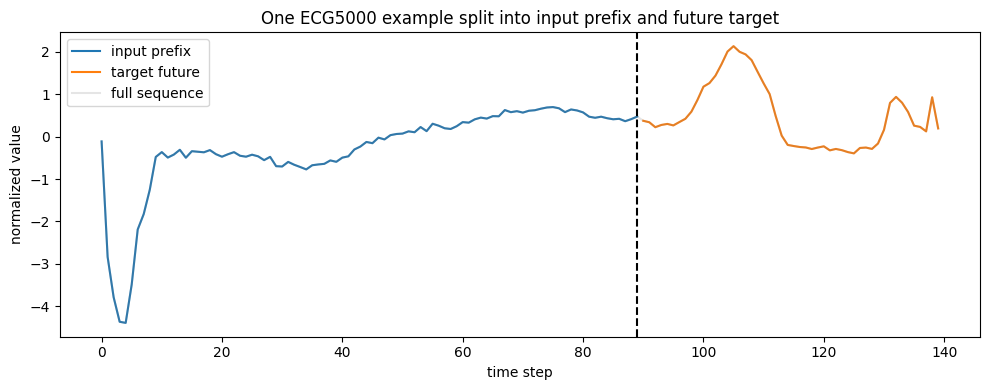

In [4]:
# ---------------------------------------
# Turn each full ECG sequence into:
#   x_i = observed prefix
#   y_i = future suffix

T_total = X_train_norm.shape[1]  # should be 140
T_x = 90
T_y = T_total - T_x

assert T_total == 140, f"Expected sequence length 140, got {T_total}"
assert T_y > 0, "Target suffix length must be positive."

# Input sequences: first T_x steps
X_train = X_train_norm[:, :T_x]
X_test = X_test_norm[:, :T_x]

# Target output sequences: final T_y steps
Y_train = X_train_norm[:, T_x:]
Y_test = X_test_norm[:, T_x:]

# Add a feature dimension F = 1 because the ECG is univariate
X_train = X_train[:, :, None]  # [N, T_x, 1]
X_test = X_test[:, :, None]    # [N, T_x, 1]
Y_train = Y_train[:, :, None]  # [N, T_y, 1]
Y_test = Y_test[:, :, None]    # [N, T_y, 1]

print("Input train shape X_train:", X_train.shape)
print("Target train shape Y_train:", Y_train.shape)
print("Input test shape  X_test: ", X_test.shape)
print("Target test shape Y_test: ", Y_test.shape)

print(f"T_x = {T_x}, T_y = {T_y}, F_x = {X_train.shape[2]}, F_y = {Y_train.shape[2]}")

# Quick sanity-check plot
example_idx = 0
full_example = np.concatenate(
    [X_train[example_idx, :, 0], Y_train[example_idx, :, 0]],
    axis=0
)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(T_x), X_train[example_idx, :, 0], label="input prefix")
plt.plot(np.arange(T_x, T_x + T_y), Y_train[example_idx, :, 0], label="target future")
plt.plot(np.arange(T_total), full_example, alpha=0.2, color="gray", label="full sequence")
plt.axvline(T_x - 1, linestyle="--", color="black")
plt.title("One ECG5000 example split into input prefix and future target")
plt.xlabel("time step")
plt.ylabel("normalized value")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Set up the DataLoader for training/validation/testing

All input sequences here have the same input length `T_x`, and all target sequences have the same output length `T_y`.  
So batching is straightforward.

Typical batch shapes are:

- `x in [B, T_x, F_x]`
- `y in [B, T_y, F_y]`

We will make a validation split from the training set.

In [6]:

# ---------------------------------------
# 3) Set up TensorDatasets and DataLoaders
# ---------------------------------------

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

# Build train dataset
full_train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

# Split original training set into train/validation
val_fraction = 0.2
n_total = len(full_train_dataset)
n_val = int(n_total * val_fraction)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

In [7]:
BATCH_SIZE = 64 # you can change this ofc

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))
print("Test size: ", len(test_dataset))

# Quick sanity check: inspect one batch
for x_batch, y_batch in train_loader:
    break

print("x_batch shape:", x_batch.shape)  # [B, T_x, F_x]
print("y_batch shape:", y_batch.shape)  # [B, T_y, F_y]

Train size: 4000
Val size:   1000
Test size:  4500
x_batch shape: torch.Size([64, 90, 1])
y_batch shape: torch.Size([64, 50, 1])


## 4. Build the autoregressive recurrent model

An autoregressive recurrent model usually has **3 parts**:

### A) Encoder
Reads the input sequence and produces a context representation `c`.

`x -> [RNN / GRU / LSTM encoder] -> c`

Input shape:
- `x in [B, T_x, F_x]`

Typical context shape:
- `c = h_T in [B, H]`

For LSTM, remember that the recurrent layer also has a **cell state**.  
Do not confuse the encoder **context** `c` with the LSTM **cell state**.

### B) Decoder
Generates the output one step at a time:

`s_tau = f_dec(s_(tau-1), y_tilde_(tau-1), c)`

where `y_tilde_(tau-1)` means:
- true previous target during training (**teacher forcing**)
- previous prediction during inference

### C) Output head
Maps each decoder state to one predicted output step:

`s_tau -> [Linear layer] -> y_hat_tau`

So overall:

`x_1, ..., x_Tx -> Encoder -> c -> Decoder -> y_hat_1, y_hat_2, ..., y_hat_Ty`

In [16]:
# 4) Build an encoder-decoder autoregressive recurrent model

# fisrt the encoder: it read the seuqence and give out the context vector and full h vector (called it  h_n).
class Encoder(nn.Module):
    """Recurrent encoder: reads the input sequence and returns context."""

    def __init__(self, input_size: int, hidden_size: int, model_type: str = "GRU"):
        super().__init__()
        self.model_type = model_type.upper()
        self.hidden_size = hidden_size

        if self.model_type == "RNN":
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        elif self.model_type == "GRU":
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        elif self.model_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            raise ValueError("model_type must be one of: 'RNN', 'GRU', 'LSTM'")

    def forward(self, x):
        """
        x shape: [B, T_x, F_x]
        T_x was the lenght of input seq
        F_x was the dimession of the input feature vector
        
        Returns:
        - context: [B, H]
        -note that H is the dimessionof hidden 
        - recurrent final state(s), which the decoder can use
        """
        
        if self.model_type == "LSTM":
            # LSTM returns final hidden state h_n and final cell state c_n
            output, (h_n, c_n) = self.rnn(x)
            context = h_n[-1]   # [B, H]
            return context, (h_n, c_n)
        else:
            output, h_n = self.rnn(x)
            context = h_n[-1]   # [B, H]
            return context, h_n


# Second the decoder as a seperate class.
# note tha we built it modular, so in future we can treat ther change these as lego piece to build a bigger network
class Decoder(nn.Module):
    """Autoregressive recurrent decoder: generates one output step at a time."""

    def __init__(self, output_size: int, hidden_size: int, model_type: str = "GRU"):
        super().__init__()
        self.model_type = model_type.upper()
        self.hidden_size = hidden_size
        self.output_size = output_size

        if self.model_type == "RNN":
            self.rnn = nn.RNN(output_size, hidden_size, batch_first=True)
        elif self.model_type == "GRU":
            self.rnn = nn.GRU(output_size, hidden_size, batch_first=True)
        elif self.model_type == "LSTM":
            self.rnn = nn.LSTM(output_size, hidden_size, batch_first=True)
        else:
            raise ValueError("model_type must be one of: 'RNN', 'GRU', 'LSTM'")

        # Linear head: decoder hidden state -> predicted output step
        self.output_head = nn.Linear(hidden_size, output_size)


    # this will generate "ONE" step of the output. int the final constructed model, we will feed it as an autoregressive seuqence generator
    def forward_step(self, decoder_input, hidden):
        """
        Run one autoregressive decoder step.

        decoder_input shape: [B, 1, F_y]
        hidden:
            - for RNN/GRU: h_n
            - for LSTM: (h_n, c_n)

        Returns:
        - prediction at current step: [B, 1, F_y]
        - updated hidden state
        """
        output, hidden = self.rnn(decoder_input, hidden)

        # output shape: [B, 1, H]
        pred = self.output_head(output)  # [B, 1, F_y]
        return pred, hidden


# finally, we will put the encoder, and decoder block together, making the autoregressive logic work
class EncoderDecoderForecaster(nn.Module):
    """Encoder-decoder recurrent model for autoregressive sequence forecasting."""

    def __init__(self, input_size: int, output_size: int, hidden_size: int, model_type: str = "GRU"):
        super().__init__()
        self.model_type = model_type.upper()

        self.encoder = Encoder(input_size=input_size, hidden_size=hidden_size, model_type=model_type)
        self.decoder = Decoder(output_size=output_size, hidden_size=hidden_size, model_type=model_type)

    def forward(self, x, target_seq=None, teacher_forcing_ratio=0.0):
        """
        x shape: [B, T_x, F_x]
        target_seq shape: [B, T_y, F_y] or None

        If target_seq is given and teacher_forcing_ratio > 0,
        the decoder may use the true previous target step.

        Returns:
        - predictions of shape [B, T_y, F_y]
        """

        
        # A_______________Encode the full input sequence into a context / final recurrent state
        context, hidden = self.encoder(x)

        if target_seq is None:
            raise ValueError("For this notebook, target_seq must be provided to define decoder length.")

        T_y = target_seq.size(1)

        # Start token for continuous forecasting:
        # use the last observed input value as the first decoder input
        decoder_input = x[:, -1:, :]  # [B, 1, F_x], and here F_x = F_y = 1

        all_predictions = []
        
        # B_______________ now generate the output in an autoregressive manner, note the "for loop" we used to generate the output
        for t in range(T_y):
            
            # One autoregressive decoder step
            pred_t, hidden = self.decoder.forward_step(decoder_input, hidden)
            all_predictions.append(pred_t)

            
            # --------Teacher forcing during training:
            # feed the true previous target with some probability
            use_teacher = random.random() < teacher_forcing_ratio
            if use_teacher:
                decoder_input = target_seq[:, t:t+1, :]
            else:
                # In inference/autoregressive mode, feed back the model prediction
                decoder_input = pred_t.detach()

        # Concatenate all predicted steps across decoder time
        predictions = torch.cat(all_predictions, dim=1)  # [B, T_y, F_y]
        
        return predictions


In [24]:
# ---------------------------------------
# Instantiate the autoregressive model

INPUT_SIZE = X_train.shape[2]   # F_x = 1
OUTPUT_SIZE = Y_train.shape[2]  # F_y = 1
HIDDEN_SIZE = 64
MODEL_TYPE = "GRU"              # try: "RNN", "GRU", "LSTM"

model = EncoderDecoderForecaster(
    input_size=INPUT_SIZE,
    output_size=OUTPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    model_type=MODEL_TYPE,
).to(device)

print(model)

# Quick forward-shape check
with torch.no_grad():
    dummy_pred = model(x_batch.to(device), y_batch.to(device), teacher_forcing_ratio=0.0)
print("Predicted sequence shape:", dummy_pred.shape)  # [B, T_y, F_y]

EncoderDecoderForecaster(
  (encoder): Encoder(
    (rnn): GRU(1, 64, batch_first=True)
  )
  (decoder): Decoder(
    (rnn): GRU(1, 64, batch_first=True)
    (output_head): Linear(in_features=64, out_features=1, bias=True)
  )
)
Predicted sequence shape: torch.Size([64, 50, 1])


## 5. Define a proper loss function based on `Y`

Here the target output sequence is **continuous**, so we use a regression loss.

For an autoregressive sequence-to-sequence task, we compute loss over **all decoder time steps**.

Since all sequences here have the same target length, we do not need masking.

In [25]:
# ---------------------------------------
# 5) Define loss function and optimizer

# Continuous output sequence -> regression loss
criterion = nn.MSELoss()

# Adam is a good default optimizer for this notebook
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 6. Define the train and test functions

The encoder reads the input sequence and outputs a context representation.  
The decoder then rolls forward one step at a time.

- **Training:** often uses **teacher forcing**
- **Inference / evaluation:** uses the model's own previous prediction

So the decoder is truly **autoregressive**.

In [26]:

# ---------------------------------------
# 6) Define train / validation / test functions
# ---------------------------------------

def run_epoch(model, loader, criterion, optimizer=None, teacher_forcing_ratio=0.0):
    """
    Run one full pass over a loader.

    If optimizer is provided:
      - model trains
      - gradients are computed and updated

    Else:
      - model evaluates only
    """
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            pred_batch = model(
                x_batch,
                target_seq=y_batch,
                teacher_forcing_ratio=teacher_forcing_ratio
            )
            loss = criterion(pred_batch, y_batch)

            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = x_batch.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    mean_loss = total_loss / total_count
    return mean_loss


@torch.no_grad()
def predict_batch(model, x_batch, y_batch=None):
    """Generate predictions with pure autoregressive decoding (no teacher forcing)."""
    model.eval()
    x_batch = x_batch.to(device)
    if y_batch is not None:
        y_batch = y_batch.to(device)

    pred = model(x_batch, target_seq=y_batch, teacher_forcing_ratio=0.0)
    return pred.cpu()

## 7. Define training and run the training

We now run the standard training loop:

- train on the training set
- evaluate on the validation set
- save the best model
- inspect final predictions on the test set

Epoch 01 | train loss: 1.155113 | val loss: 1.008485
Epoch 02 | train loss: 0.927045 | val loss: 0.904203
Epoch 03 | train loss: 0.900834 | val loss: 0.890626
Epoch 04 | train loss: 0.877857 | val loss: 0.842048
Epoch 05 | train loss: 0.689060 | val loss: 0.550705
Epoch 06 | train loss: 0.537972 | val loss: 0.563692
Epoch 07 | train loss: 0.523481 | val loss: 0.509010
Epoch 08 | train loss: 0.507646 | val loss: 0.460830
Epoch 09 | train loss: 0.472662 | val loss: 0.439011
Epoch 10 | train loss: 0.483577 | val loss: 0.453548
Epoch 11 | train loss: 0.465634 | val loss: 0.448610
Epoch 12 | train loss: 0.448880 | val loss: 0.419687
Epoch 13 | train loss: 0.428100 | val loss: 0.409051
Epoch 14 | train loss: 0.418475 | val loss: 0.411215
Epoch 15 | train loss: 0.405238 | val loss: 0.385025
Epoch 16 | train loss: 0.402141 | val loss: 0.399799
Epoch 17 | train loss: 0.393071 | val loss: 0.380589
Epoch 18 | train loss: 0.374878 | val loss: 0.357056
Epoch 19 | train loss: 0.363513 | val loss: 0.

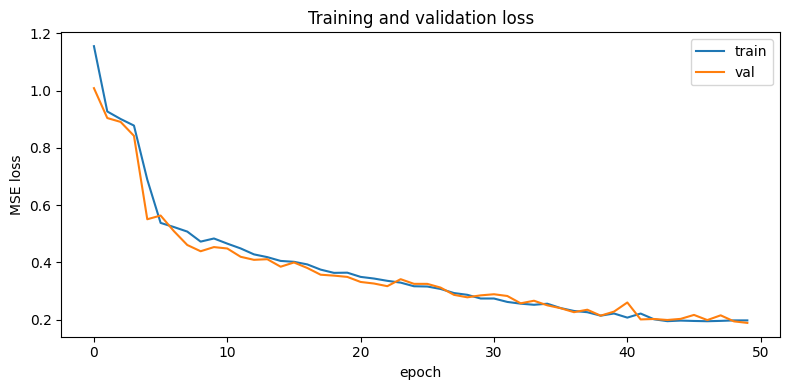

In [27]:
# ---------------------------------------
# 7) Train the model and inspect results

NUM_EPOCHS = 50
TEACHER_FORCING_RATIO = 0.0

best_val_loss = float("inf")
best_state_dict = None

train_losses = []
val_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        teacher_forcing_ratio=TEACHER_FORCING_RATIO,
    )

    val_loss = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        teacher_forcing_ratio=0.0,
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch:02d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

# Load the best validation model
model.load_state_dict(best_state_dict)

# Final test loss
test_loss = run_epoch(
    model,
    test_loader,
    criterion,
    optimizer=None,
    teacher_forcing_ratio=0.0,
)

print(f"Best val loss: {best_val_loss:.6f}")
print(f"Test loss:     {test_loss:.6f}")

# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize a few autoregressive predictions on the test set
for x_vis, y_vis in test_loader:
    break

pred_vis = predict_batch(model, x_vis, y_vis)


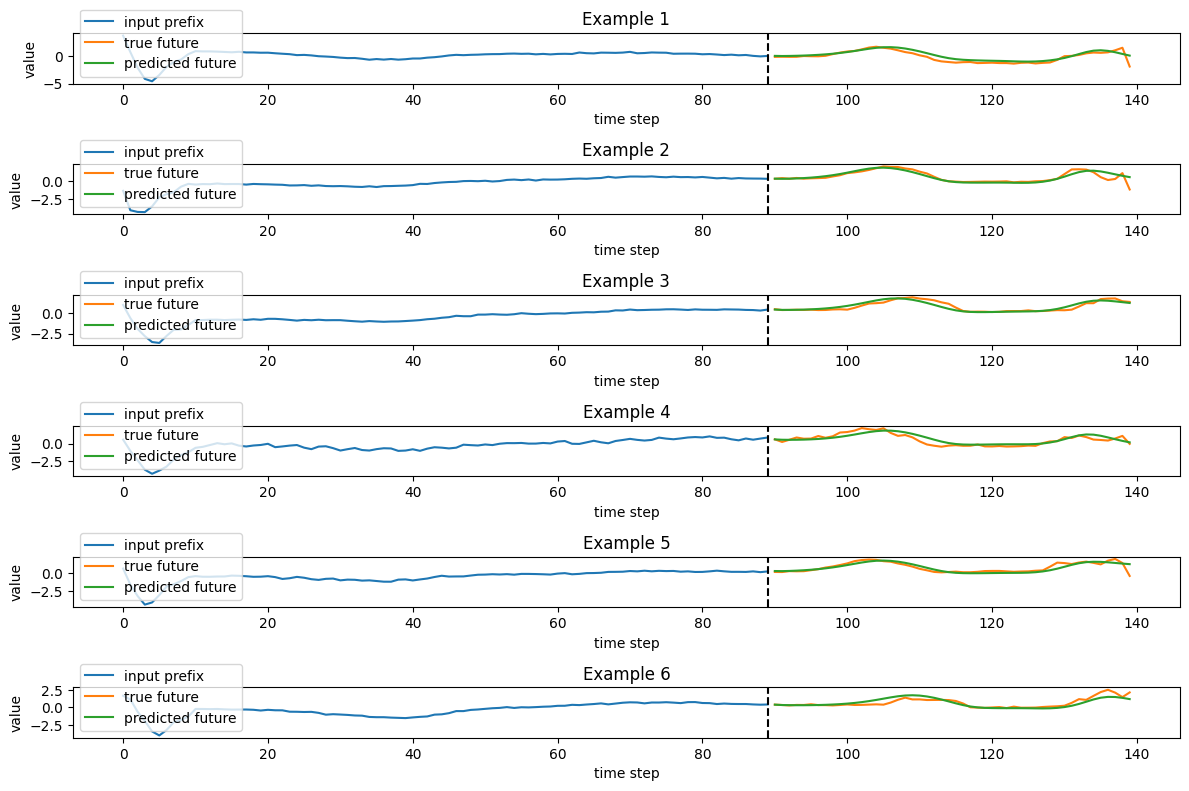

In [28]:
num_examples_to_show = 6
plt.figure(figsize=(12, 8))

for i in range(num_examples_to_show):
    prefix = x_vis[i, :, 0].numpy()
    target = y_vis[i, :, 0].numpy()
    pred = pred_vis[i, :, 0].numpy()

    prefix_t = np.arange(T_x)
    future_t = np.arange(T_x, T_x + T_y)

    plt.subplot(num_examples_to_show, 1, i + 1)
    plt.plot(prefix_t, prefix, label="input prefix")
    plt.plot(future_t, target, label="true future")
    plt.plot(future_t, pred, label="predicted future")
    plt.axvline(T_x - 1, linestyle="--", color="black")
    plt.title(f"Example {i+1}")
    plt.xlabel("time step")
    plt.ylabel("value")
    plt.legend()

plt.tight_layout()
plt.show()